## Coherence Score

This notebook evaluates topic numbers ranging from 1-20 for both thematic areas (Computer Science and Information Technology) to find the optimal number of topics to be used for LDA topic modelling.



In [1]:
# Imports 
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
from gensim.corpora import Dictionary
from gensim.models import LdaModel
from gensim.models.coherencemodel import CoherenceModel

In [2]:
# Data Loading

DATA_FILE = Path("../out/dcit_courses_skills.jsonl")
if not DATA_FILE.exists():
    raise FileNotFoundError(f"{DATA_FILE} not found.")

df = pd.read_json(DATA_FILE, lines=True)

In [3]:
# Expanding the DataFrame to have one row per thematic area

df_expanded = df.explode("thematic_areas").rename(columns={"thematic_areas": "thematic_area"})

In [4]:
# Function to normalize multi-word skills by replacing spaces with underscores

def normalize_multiword_skills(skills):
    if not isinstance(skills, list):
        return []
    return [str(skill).strip().replace(" ", "_") for skill in skills if str(skill).strip()]

df_expanded["skills"] = df_expanded["skills"].apply(normalize_multiword_skills)

In [5]:
# Function to create separate DataFrames for Computer Science and Information Technology courses

cs_df = df_expanded[df_expanded["thematic_area"]=="computer_science"].copy()
it_df = df_expanded[df_expanded["thematic_area"]=="information_technology"].copy()

cs_texts = cs_df["skills"].tolist()
it_texts = it_df["skills"].tolist()

In [6]:
# Function to remove thematic area names from the skill lists to prevent them from dominating the topic modeling results
def clean_tokens(tokens):
    return [
        t for t in tokens
        if t not in {"computer_science", "information_technology"}
    ]

cs_texts = [clean_tokens(t) for t in cs_texts]
it_texts = [clean_tokens(t) for t in it_texts]

In [7]:
# Verifying the cleaned DataFrames

cs_df.head()
it_df.head()

,course_code,course_name,thematic_area,skills
0,COMP 1600,Introduction to Computing Concepts,information_technology,"[architecture_operating, architectures_operati..."
1,COMP 1601,Computer Programming I,information_technology,"[algorithms, control_structure, numbers, param..."
2,COMP 1602,Computer Programming II,information_technology,"[merge_sort, queue_priority, 2d, adding, algor..."
3,COMP 1603,Computer Programming III,information_technology,"[coding_errors, data_structures, arithmetic, b..."
4,COMP 1604,Mathematics for Computing,information_technology,"[basic_structure, basic_structures, computer_p..."


In [ ]:
# Function to evaluate coherence scores for a range of topic numbers and return the best model and its details
def evaluate_coherence(skills, start=1, limit=20, step=1, no_below=1, no_above=0.8):
    dictionary = Dictionary(skills)
    dictionary.filter_extremes(no_below=no_below, no_above=no_above)

    corpus = [dictionary.doc2bow(skill) for skill in skills]

    model_list = []
    coherence_values = []
    topic_range = list(range(start, limit, step))

    for num_topics in topic_range:
        model = LdaModel(
            corpus=corpus,
            id2word=dictionary,
            num_topics=num_topics,
            random_state=42,
            passes=10,
            iterations=100
        )

        coherence_model = CoherenceModel(
            model=model,
            texts=skills,
            dictionary=dictionary,
            coherence="c_v"
        )

        model_list.append(model)
        coherence_values.append(coherence_model.get_coherence())

    best_index = coherence_values.index(max(coherence_values))

    return {
        "dictionary": dictionary,
        "corpus": corpus,
        "topic_range": topic_range,
        "model_list": model_list,
        "coherence_values": coherence_values,
        "best_model": model_list[best_index],
        "best_num_topics": topic_range[best_index],
        "best_coherence": coherence_values[best_index],
    }


# Computer Science Topic Evaluation


Computer Science Coherence Scores: 
Number of Topics: 1, Coherence Score: 0.3042
Number of Topics: 2, Coherence Score: 0.2840
Number of Topics: 3, Coherence Score: 0.3588
Number of Topics: 4, Coherence Score: 0.3763
Number of Topics: 5, Coherence Score: 0.3990
Number of Topics: 6, Coherence Score: 0.5181
Number of Topics: 7, Coherence Score: 0.4746
Number of Topics: 8, Coherence Score: 0.4900
Number of Topics: 9, Coherence Score: 0.4884
Number of Topics: 10, Coherence Score: 0.6189
Number of Topics: 11, Coherence Score: 0.6386
Number of Topics: 12, Coherence Score: 0.6359
Number of Topics: 13, Coherence Score: 0.6573
Number of Topics: 14, Coherence Score: 0.7015
Number of Topics: 15, Coherence Score: 0.6550
Number of Topics: 16, Coherence Score: 0.6961
Number of Topics: 17, Coherence Score: 0.6781
Number of Topics: 18, Coherence Score: 0.7844
Number of Topics: 19, Coherence Score: 0.6170


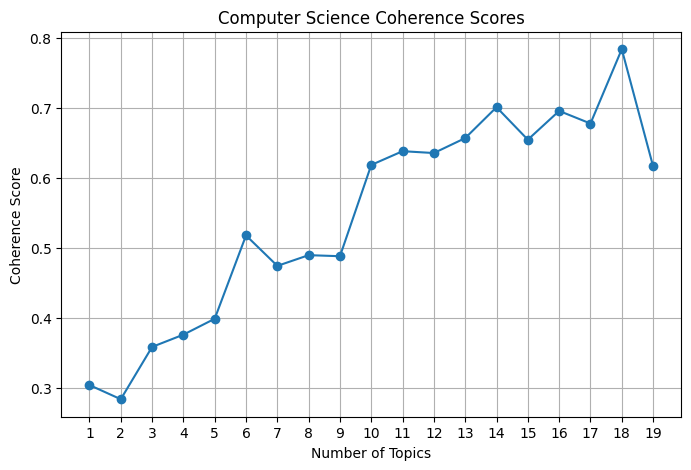

Optimal Number of Topics: 18
Coherence Score: 0.7844

Top 10 Words per Topic 18: 

Topic: 0: 0.008*"cognitive_model" + 0.008*"interaction_design" + 0.008*"teamwork" + 0.008*"online_communities" + 0.008*"social_medium" + 0.008*"presentations" + 0.004*"parallel_processing" + 0.004*"communication_system" + 0.004*"route_protocol" + 0.004*"application_level"

Topic: 1: 0.011*"management_system" + 0.011*"sql" + 0.011*"database_management_system" + 0.006*"programming" + 0.006*"algorithms" + 0.006*"collision_detection" + 0.006*"virtual_reality" + 0.006*"distribution_functions" + 0.006*"time_series" + 0.006*"model_building"

Topic: 2: 0.023*"develop_software" + 0.023*"project_management" + 0.023*"software_system" + 0.016*"milestones" + 0.016*"apply_research" + 0.016*"software_documentation" + 0.016*"timelines" + 0.016*"design_solutions" + 0.016*"project_plan" + 0.016*"problem_solve"

Topic: 3: 0.001*"operations" + 0.001*"mobile_applications" + 0.001*"management" + 0.001*"supply_chain_management

In [9]:
cs_results = evaluate_coherence(cs_texts, start=1, limit=20, step=1)

print("Computer Science Coherence Scores: ")
for k, score in zip(cs_results["topic_range"], cs_results["coherence_values"]):
    print(f"Number of Topics: {k}, Coherence Score: {score:.4f}")


plt.figure(figsize=(8, 5))
plt.plot(cs_results["topic_range"], cs_results["coherence_values"], marker="o")
plt.xlabel("Number of Topics")
plt.ylabel("Coherence Score")
plt.title("Computer Science Coherence Scores")
plt.xticks(cs_results["topic_range"])
plt.grid(True)
plt.show()

print(f"Optimal Number of Topics: {cs_results['best_num_topics']}")
print(f"Coherence Score: {cs_results['best_coherence']:.4f}")
topics = cs_results["best_model"].print_topics(num_words=10)
print(f"\nTop 10 Words per Topic {cs_results['best_num_topics']}: ")
for topic_num, topic_words in topics:
    print(f"\nTopic: {topic_num}: {topic_words}")


# Information Technology Topic Evaluation 

Information Technology Coherence Scores: 
Number of Topics: 1, Coherence Score: 0.2202
Number of Topics: 2, Coherence Score: 0.2723
Number of Topics: 3, Coherence Score: 0.3034
Number of Topics: 4, Coherence Score: 0.3247
Number of Topics: 5, Coherence Score: 0.3519
Number of Topics: 6, Coherence Score: 0.4546
Number of Topics: 7, Coherence Score: 0.5468
Number of Topics: 8, Coherence Score: 0.3980
Number of Topics: 9, Coherence Score: 0.5458
Number of Topics: 10, Coherence Score: 0.5211
Number of Topics: 11, Coherence Score: 0.6875
Number of Topics: 12, Coherence Score: 0.6905
Number of Topics: 13, Coherence Score: 0.6983
Number of Topics: 14, Coherence Score: 0.7571
Number of Topics: 15, Coherence Score: 0.8300
Number of Topics: 16, Coherence Score: 0.7815
Number of Topics: 17, Coherence Score: 0.7622
Number of Topics: 18, Coherence Score: 0.8573
Number of Topics: 19, Coherence Score: 0.7999


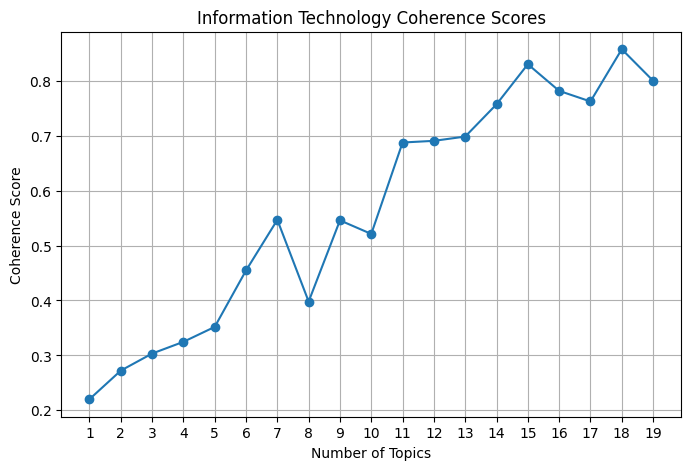

Optimal Number of Topics: 18
Coherence Score: 0.8573

Top 10 Words per Topic 18: 

Topic: 0: 0.011*"simulations" + 0.011*"calibration" + 0.011*"random_number" + 0.011*"system_design" + 0.011*"real_data" + 0.011*"discrete_event" + 0.011*"forecasting" + 0.011*"distribution_functions" + 0.011*"discrete_event_simulation" + 0.011*"model_building"

Topic: 1: 0.009*"motion_capture" + 0.009*"integration" + 0.009*"inverse_kinematic" + 0.009*"human_computer_interaction" + 0.009*"data_structures" + 0.009*"technical_documentation" + 0.009*"rigid_body" + 0.009*"game_physics" + 0.009*"software_configuration_management" + 0.009*"programming_language"

Topic: 2: 0.011*"programming" + 0.011*"teamwork" + 0.011*"web_application" + 0.011*"session" + 0.011*"information_system" + 0.006*"algorithms" + 0.006*"generally_accepted_principles" + 0.006*"reconnaissance" + 0.006*"password_authentication" + 0.006*"digital_asset"

Topic: 3: 0.008*"computer_system" + 0.008*"reading" + 0.008*"documentation_writing" + 0.

In [10]:
it_results = evaluate_coherence(it_texts, start=1, limit=20, step=1)

print("Information Technology Coherence Scores: ")
for k, score in zip(it_results["topic_range"], it_results["coherence_values"]):
    print(f"Number of Topics: {k}, Coherence Score: {score:.4f}")


plt.figure(figsize=(8, 5))
plt.plot(it_results["topic_range"], it_results["coherence_values"], marker="o")
plt.xlabel("Number of Topics")
plt.ylabel("Coherence Score")
plt.title("Information Technology Coherence Scores")
plt.xticks(it_results["topic_range"])
plt.grid(True)
plt.show()

print(f"Optimal Number of Topics: {it_results['best_num_topics']}")
print(f"Coherence Score: {it_results['best_coherence']:.4f}")
topics = it_results["best_model"].print_topics(num_words=10)
print(f"\nTop 10 Words per Topic {it_results['best_num_topics']}: ")
for topic_num, topic_words in topics:
    print(f"\nTopic: {topic_num}: {topic_words}")